In [1]:
import os
import numpy as np
import pandas as pd

import networkx as nx
import matplotlib.pyplot as plt

from tqdm import tqdm
import json

# allow imports from utils/
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load node and edge colors

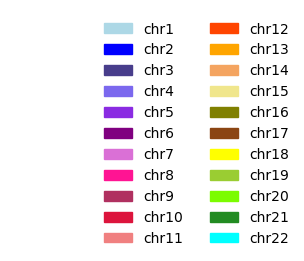

In [2]:
import matplotlib.patches as mpatches

# Create legend for chromosomes
c32_palette = [
    (173, 216, 230),
    (0, 0, 255),
    (72, 61, 139),
    (123, 104, 238),
    (138, 43, 226),
    (128, 0, 128),
    (218, 112, 214),
    (255, 20, 147),
    (176, 48, 96),
    (220, 20, 60),
    (240, 128, 128),
    (255, 69, 0),
    (255, 165, 0),
    (244, 164, 96),
    (240, 230, 140),
    (128, 128, 0),
    (139, 69, 19),
    (255, 255, 0),
    (154, 205, 50),
    (124, 252, 0),
    (34, 139, 34),
    (0, 255, 255),
    (0, 139, 139),
    (128, 128, 128),
]

from colormap import rgb2hex

c32_palette = [rgb2hex(c[0], c[1], c[2]) for c in c32_palette]


colors = list(c32_palette)
node_color_dict = {
    f"chr{chrom}": colors[chrom - 1] for chrom in np.arange(1, 22 + 1, 1)
}
legend_patches = [
    mpatches.Patch(color=color, label=label) for label, color in node_color_dict.items()
]

fig, ax = plt.subplots(figsize=(1, 1))
ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2,
    frameon=False,
)
ax.axis("off")

# plt.savefig(f"{FIGURE_DIR}main/fig3/chrom_legend.svg", bbox_inches = 'tight')
plt.show()

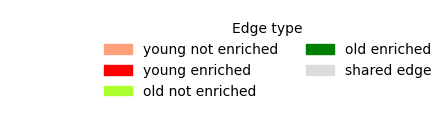

In [3]:
# Create legend for edges
edge_color_dict = {
    "young not enriched": "lightsalmon",
    "young enriched": "red",
    "old not enriched": "greenyellow",
    "old enriched": "green",
    "shared edge": "gainsboro",
}
legend_patches = [
    mpatches.Patch(color=color, label=label) for label, color in edge_color_dict.items()
]

fig, ax = plt.subplots(figsize=(1, 1))
ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2,
    frameon=False,
    title="Edge type",
)
ax.axis("off")
# plt.savefig(f"{FIGURE_DIR}main/fig3/edge_type_legend.svg", bbox_inches = 'tight')

plt.show()

# Load final LAS network

We load the LAS network of Hi-C edges betweeen old and young fibroblasts. 

## TODO: Organize code to generate the network

In [4]:
import pickle

# Load network including intraX contiguous edges
fname = (
    f"../data/young_old/unthresholded_intraXaugmented_las_network_lifted.pkl"
)
with open(fname, "rb") as handle:
    G, node_attributes_df, edge_attributes_df = pickle.load(handle)

TODO: Current graph has too much extra stuff we don't need.

In [5]:
attrs = set()

for _, data in G.nodes(data=True):
    attrs.update(data.keys())

list(attrs)

['n_genes_REACTOME_CELLULAR_SENESCENCE',
 'norm_ncrna_rnaseq_count_old1',
 'ncrna_bs',
 'genes_REACTOME_TGF_BETA',
 'norm_rnaseq_count_young2',
 'start',
 'norm_rnaseq_count_old2',
 'n_genes_SAUL_SEN_MAYO',
 'genes_HALLMARK_TNFA_SIGNALING_VIA_NFKB',
 'ncrna_gene',
 'n_genes_HALLMARK_TNFA_SIGNALING_VIA_NFKB',
 'norm_ncrna_rnaseq_count_old2',
 'n_genes_HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
 'age',
 'n_genes_REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP',
 'genes_HALLMARK_TGF_BETA_SIGNALING',
 'n_genes_HALLMARK_TGF_BETA_SIGNALING',
 'norm_pc_rnaseq_count_old2',
 'genes_KEGG_TGF_BETA_SIGNALING_PATHWAY',
 'nads',
 'norm_pc_rnaseq_count_young2',
 'chrom',
 'old_exp',
 'genes_REACTOME_TNF_SIGNALING',
 'norm_ncrna_rnaseq_count_young2',
 'n_ncrna_bs',
 'n_binding_ncrna',
 'binding_ncrna',
 'end',
 'norm_rnaseq_count_old1',
 'norm_pc_rnaseq_count_old1',
 'norm_pc_rnaseq_count_young1',
 'n_genes_KEGG_TGF_BETA_SIGNALING_PATHWAY',
 'genes_REACTOME_CELLULAR_SENESCENCE',
 'n_nads',
 

# Split graph into young enriched and old enriched edge subgraphs

We subset the graph based on edge enrichment. In particular, edges can be present in an young or old-specific manner.

We also annotate edges that connect lncRNA binding sites.

## Load edge enrichment labels
## TODO: Code for how this is generated

In [6]:
observed_edge_enrichment_results = pd.read_hdf(
    '../data/young_old/observed_edge_enrichment_results_lifted.h5', key=None, mode="r", errors="strict"
)
observed_edge_enrichment_results.head()

,edge_id,age,n_age_specific_ncrnas,n_anti_age_specific_ncrnas,n_edge_ncrnas,pure_edge,anti_pure_edge,ncrna_pval,neglog_ncrna_pval,observation_type
0,las_chr10_25000000_25250000-las_chr12_39250000...,old,0,0,1,False,False,1.0,-0.0,observed
1,las_chr10_25000000_25250000-las_chr12_39500000...,old,0,0,1,False,False,1.0,-0.0,observed
2,las_chr10_25000000_25250000-las_chr12_39750000...,old,0,0,1,False,False,1.0,-0.0,observed
3,las_chr10_25000000_25250000-las_chr12_40000000...,old,0,1,3,False,False,1.0,-0.0,observed
4,las_chr10_25000000_25250000-las_chr12_40250000...,old,0,0,2,False,False,1.0,-0.0,observed


In [7]:
# Enriched edges
alpha = 0.1

# Enriched young edges
enriched_young_edges_list = observed_edge_enrichment_results[
    (observed_edge_enrichment_results["age"] == "young")
    & (observed_edge_enrichment_results["ncrna_pval"] <= alpha)
]["edge_id"].values
print(
    f"Number of young-pure and ncRNA-enriched edges = {len(enriched_young_edges_list)}"
)
print(
    f"Percentage of total = {len(enriched_young_edges_list)/len(observed_edge_enrichment_results)*100}"
)

# Enriched old edges
enriched_old_edges_list = observed_edge_enrichment_results[
    (observed_edge_enrichment_results["age"] == "old")
    & (observed_edge_enrichment_results["ncrna_pval"] <= alpha)
]["edge_id"].values
print(f"Number of old-pure and ncRNA-enriched edges = {len(enriched_old_edges_list)}")
print(
    f"Percentage of total = {len(enriched_old_edges_list)/len(observed_edge_enrichment_results)*100}"
)

Number of young-pure and ncRNA-enriched edges = 7530
Percentage of total = 0.4834174338430723
Number of old-pure and ncRNA-enriched edges = 8655
Percentage of total = 0.5556411540387505


## Subset to young-enriched subgraph

In [8]:
# Select only young enriched edges
edges_to_keep = [(e.split("-")[0], e.split("-")[1]) for e in enriched_young_edges_list]
subG_enriched = G.edge_subgraph(edges_to_keep).copy()
print(subG_enriched)

Graph with 1342 nodes and 7530 edges


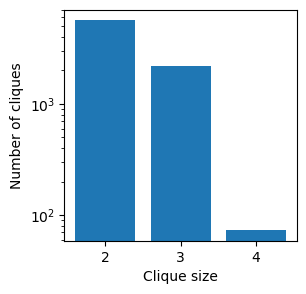

In [9]:
# Identify all maximal cliques in graph
all_cliques = nx.find_cliques_recursive(subG_enriched)
all_cliques = list(all_cliques)
all_cliques_size = [len(c) for c in all_cliques]
x, h = np.unique(all_cliques_size, return_counts=True)

plt.figure(figsize=(3, 3))
plt.bar(x, h)
plt.yscale("log")
plt.xlabel("Clique size")
plt.ylabel("Number of cliques")
plt.show()

In [10]:
clique_2_nodes = set().union(
    *(set(clique) for clique in all_cliques if len(clique) >= 2)
)

clique_2_subG_young = subG_enriched.subgraph(clique_2_nodes).copy()

## Subset to old-enriched subgraph

In [11]:
# Select only young enriched edges
edges_to_keep = [(e.split("-")[0], e.split("-")[1]) for e in enriched_old_edges_list]
subG_enriched = G.edge_subgraph(edges_to_keep).copy()
print(subG_enriched)

Graph with 2394 nodes and 8655 edges


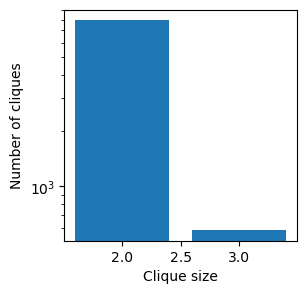

In [12]:
# Identify all maximal cliques in graph
all_cliques = nx.find_cliques_recursive(subG_enriched)
all_cliques = list(all_cliques)
all_cliques_size = [len(c) for c in all_cliques]
x, h = np.unique(all_cliques_size, return_counts=True)

plt.figure(figsize=(3, 3))
plt.bar(x, h)
plt.yscale("log")
plt.xlabel("Clique size")
plt.ylabel("Number of cliques")
plt.show()

In [13]:
clique_2_nodes = set().union(
    *(set(clique) for clique in all_cliques if len(clique) >= 2)
)

clique_2_subG_old = subG_enriched.subgraph(clique_2_nodes).copy()

# Plot subgraphs

In [14]:
from pyvis.network import Network

def create_subnetwork_html(subG_selected, node_color_dict, highlighted_edges=None):
    # Node colors by chrom
    node_colors = {
        node: node_color_dict[node_data["chrom"]]
        for node, node_data in subG_selected.nodes(data=True)
    }

    # Edge colors by age + highlight
    highlighted_edges = set(highlighted_edges) if highlighted_edges else set()
    edge_colors = {}
    for u, v, att in subG_selected.edges(data=True):
        highlighted = (not highlighted_edges or (u, v) in highlighted_edges or (v, u) in highlighted_edges)
        if att["age"] == "young":
            edge_colors[(u, v)] = "red" if highlighted else "lightsalmon"
        elif att["age"] == "old":
            edge_colors[(u, v)] = "green" if highlighted else "greenyellow"
        else:
            edge_colors[(u, v)] = "darkgray" if highlighted else "gainsboro"

    # Build pyvis graph
    pyvis_graph = Network(height="1000px", width="1000px", notebook=True, cdn_resources="in_line")
    pyvis_graph.force_atlas_2based()

    for node, node_data in subG_selected.nodes(data=True):
        pyvis_graph.add_node(node, color=node_colors[node])

    for u, v, att in subG_selected.edges(data=True):
        pyvis_graph.add_edge(u, v, color=edge_colors[(u, v)])

    pyvis_graph.show_buttons(["physics"])
    return pyvis_graph

## Fig 3e

Note the Pyvis graph `.html` version is the one we use in the manuscript.

In [15]:
to_plot = create_subnetwork_html(
    clique_2_subG_young, node_color_dict, highlighted_edges=None
)

# to_plot.save_graph("./full_young_enriched_graph.html")

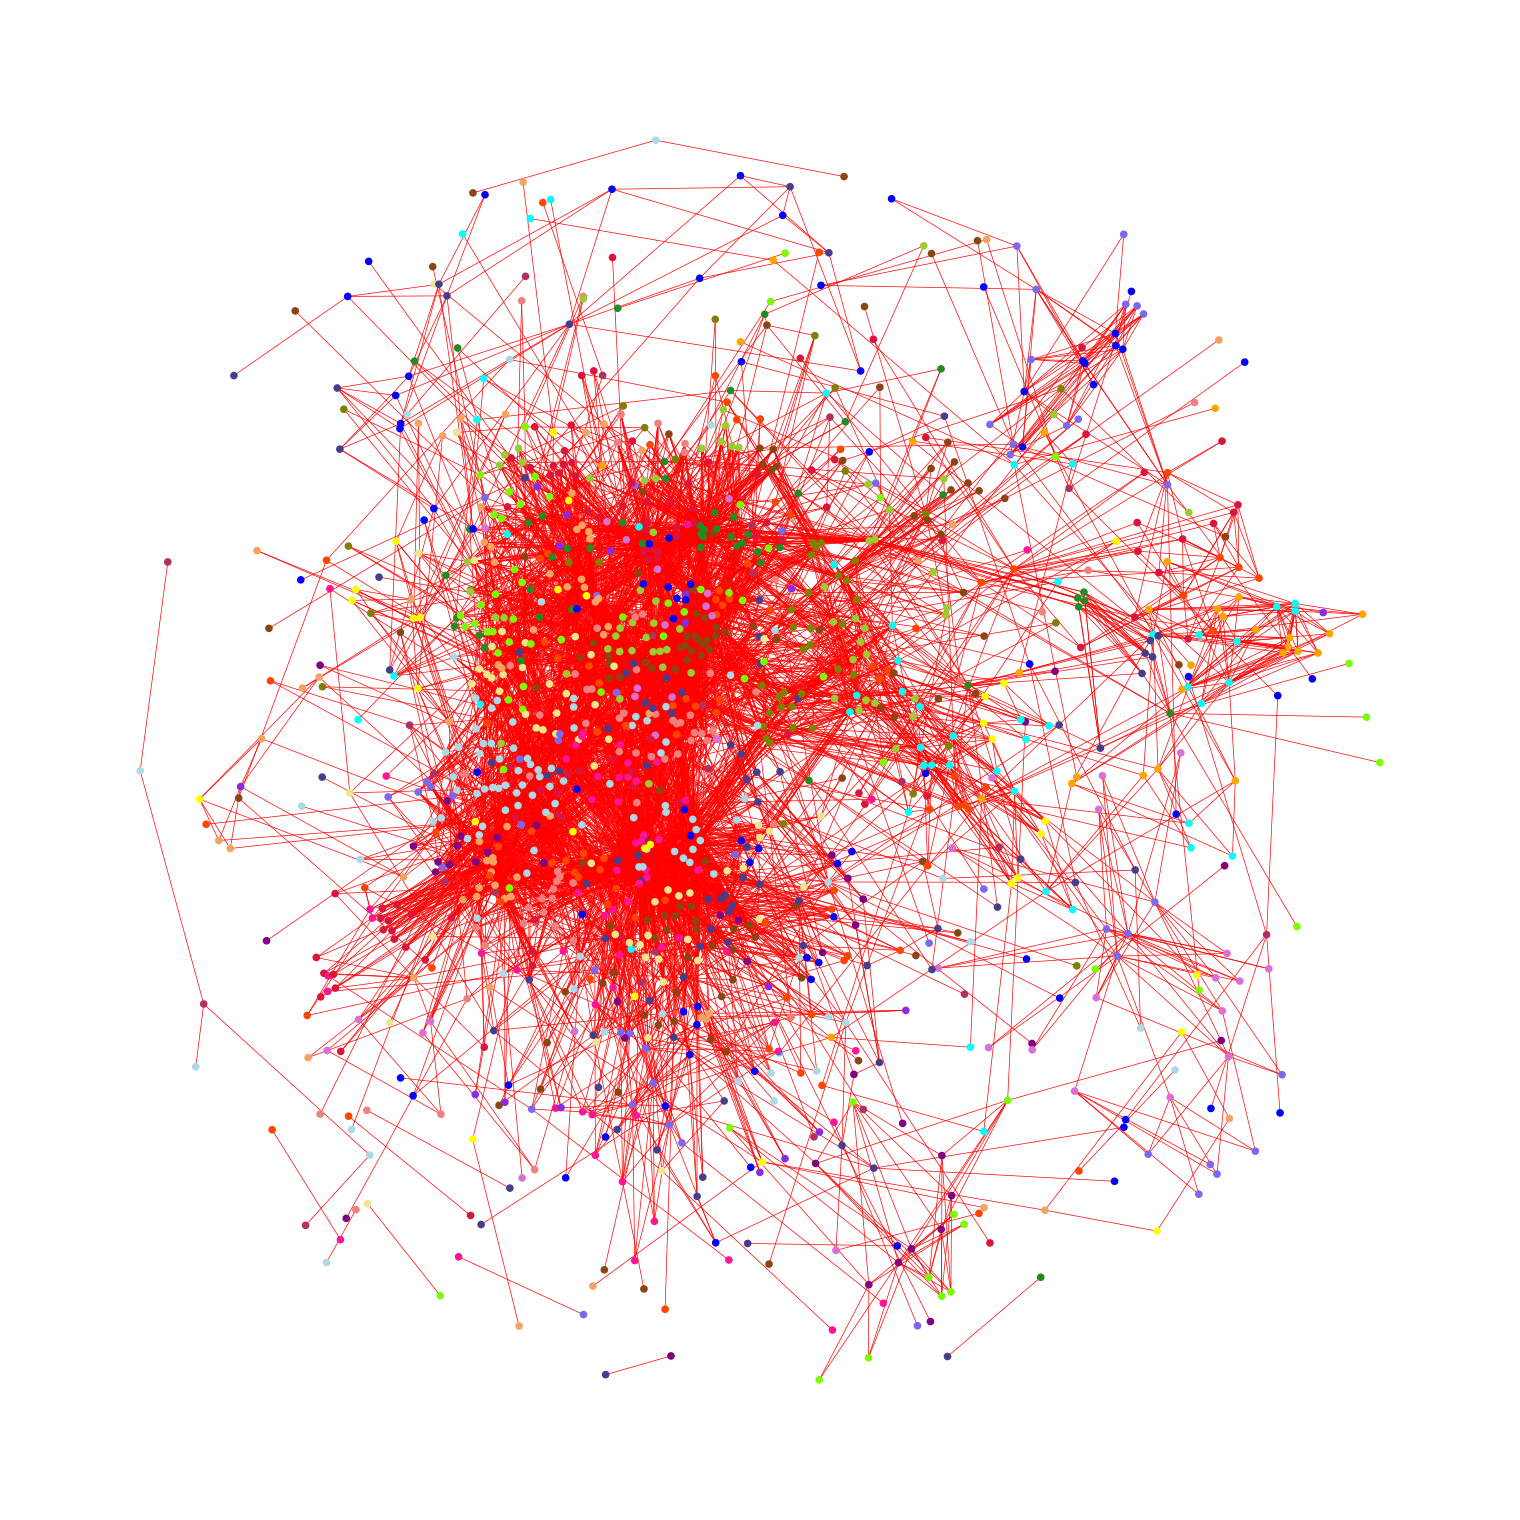

In [16]:
subG_selected = clique_2_subG_young.copy()
pos = nx.spring_layout(subG_selected, seed=42, k=10/np.sqrt(len(subG_selected.nodes())), iterations=100)
node_color_list = [node_color_dict[d["chrom"]] for n, d in subG_selected.nodes(data=True)]

plt.figure(figsize=(15, 15))
nx.draw(subG_selected, pos=pos, 
        node_color=node_color_list,
        edge_color="red",
        node_size=20,
        width=0.5)
# plt.savefig("subnetwork.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig 3f

In [17]:
to_plot = create_subnetwork_html(
    clique_2_subG_old, node_color_dict, highlighted_edges=None
)

# to_plot.save_graph("./full_old_enriched_graph.html")

# Cluster enriched graphs (Fig S13)

Next, we run louvain clustering on our young and old-specific, lncRNA enriched subgraphs to identify interesting subnetworks.

## Young enriched subgraph

[1192, 30, 27, 23, 20, 10, 6, 5, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


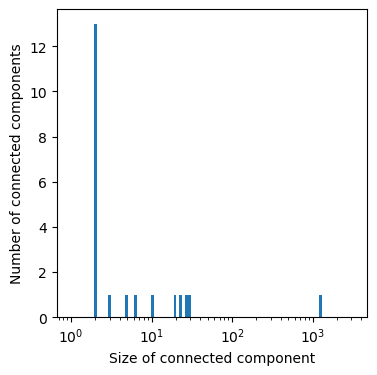

Graph with 1192 nodes and 7229 edges


In [18]:
# Number of connected components
clique2_components = [
    c for c in sorted(nx.connected_components(clique_2_subG_young), key=len, reverse=True)
]
cc_len = [
    len(c)
    for c in sorted(nx.connected_components(clique_2_subG_young), key=len, reverse=True)
]
print(cc_len)

plt.figure(figsize=(4, 4))
plt.hist(cc_len, bins=np.logspace(0, 3.5, 100))
plt.xscale("log")
plt.xlabel("Size of connected component")
plt.ylabel("Number of connected components")
plt.show()

# Focus on largest component in order to break it down into smaller subclusters
largest_cc_nodes = clique2_components[0]
clique2_largest_cc = clique_2_subG_young.subgraph(largest_cc_nodes).copy()
print(clique2_largest_cc)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.96it/s]


Louvain resolution = 1.2067926406393288


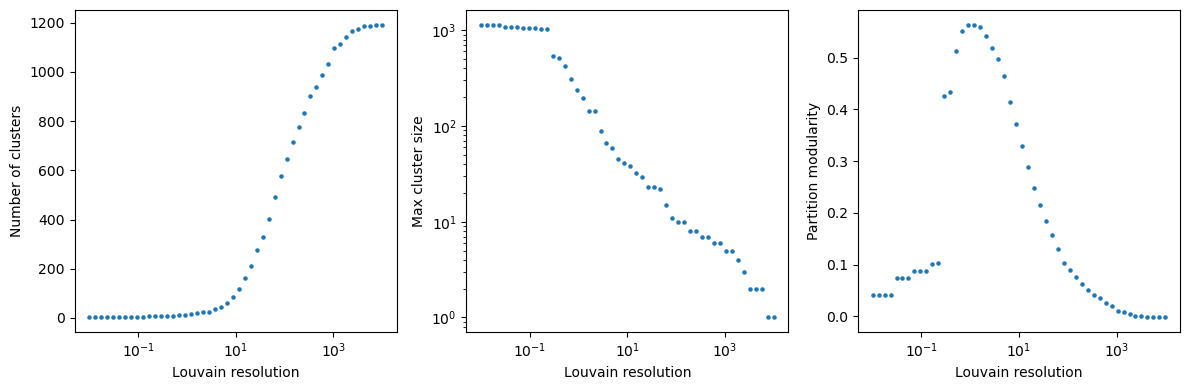

In [19]:
# Choose resolution for Louvain clustering of largest connected component

resolution_ls = np.power(10, np.linspace(-2, 4, 50))
n_clusters = []
modularity_list = []
max_clustersize_list = []
for resolution in tqdm(resolution_ls):
    # Number of clusters
    clusters = nx.community.louvain_communities(
        clique2_largest_cc,
        weight="None",
        resolution=resolution,
        threshold=1e-07,
        seed=13,
    )
    n_clusters.append(len(clusters))
    # Maximum cluster size
    max_clustersize = max([len(c) for c in clusters])
    max_clustersize_list.append(max_clustersize)
    # Modularity
    modularity = nx.community.modularity(clique2_largest_cc, clusters, resolution=1)
    modularity_list.append(modularity)

# t_louvain = 10
t_louvain = resolution_ls[np.argmax(modularity_list)]
print(f"Louvain resolution = {t_louvain}")

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=False)

ax = axs[0]
ax.scatter(resolution_ls, n_clusters, s=5)
# ax.vlines(x=t_louvain, ymin=0, ymax=max(n_clusters), color="red", linestyle="dashed")
ax.set_xscale("log")
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Number of clusters")

ax = axs[1]
ax.scatter(resolution_ls, max_clustersize_list, s=5)
# ax.vlines(
#     x=t_louvain, ymin=0, ymax=max(max_clustersize_list), color="red", linestyle="dashed"
# )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Max cluster size")

ax = axs[2]
ax.scatter(resolution_ls, modularity_list, s=5)
# ax.vlines(
#     x=t_louvain, ymin=0, ymax=max(modularity_list), color="red", linestyle="dashed"
# )
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Partition modularity")

plt.tight_layout()
plt.show()

In [20]:
# Cluster subnetwork
resolution = 10  # t_louvain
clusters = nx.community.louvain_communities(
    clique2_largest_cc, weight="None", resolution=resolution, threshold=1e-07, seed=42
)
cluster2nodes = {
    f"cluster_{idx}": sorted(clusters[idx]) for idx in range(len(clusters))
}
node2cluster = {}
for k, v in cluster2nodes.items():
    for node in v:
        node2cluster[node] = k

In [21]:
# Create list of subclusters of subG_enriched
clique2_subclusters_young = []
for i, cc in tqdm(enumerate(clique2_components)):
    if i == 0:
        for cc_cluster in clusters:
            subcluster_graph = clique_2_subG_young.subgraph(cc_cluster).copy()
            clique2_subclusters_young.append(subcluster_graph)
    else:
        subcluster_graph = clique_2_subG_young.subgraph(cc).copy()
        clique2_subclusters_young.append(subcluster_graph)

22it [00:00, 747.22it/s]


## Old enriched subgraph

[2347, 17, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


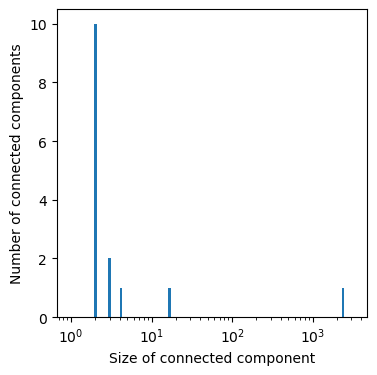

Graph with 2347 nodes and 8606 edges


In [23]:
# Number of connected components
clique2_components = [
    c for c in sorted(nx.connected_components(clique_2_subG_old), key=len, reverse=True)
]
cc_len = [
    len(c)
    for c in sorted(nx.connected_components(clique_2_subG_old), key=len, reverse=True)
]
print(cc_len)

plt.figure(figsize=(4, 4))
plt.hist(cc_len, bins=np.logspace(0, 3.5, 100))
plt.xscale("log")
plt.xlabel("Size of connected component")
plt.ylabel("Number of connected components")
plt.show()

# Focus on largest component in order to break it down into smaller subclusters
largest_cc_nodes = clique2_components[0]
clique2_largest_cc = clique_2_subG_old.subgraph(largest_cc_nodes).copy()
print(clique2_largest_cc)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.87it/s]


Louvain resolution = 0.9102981779915218


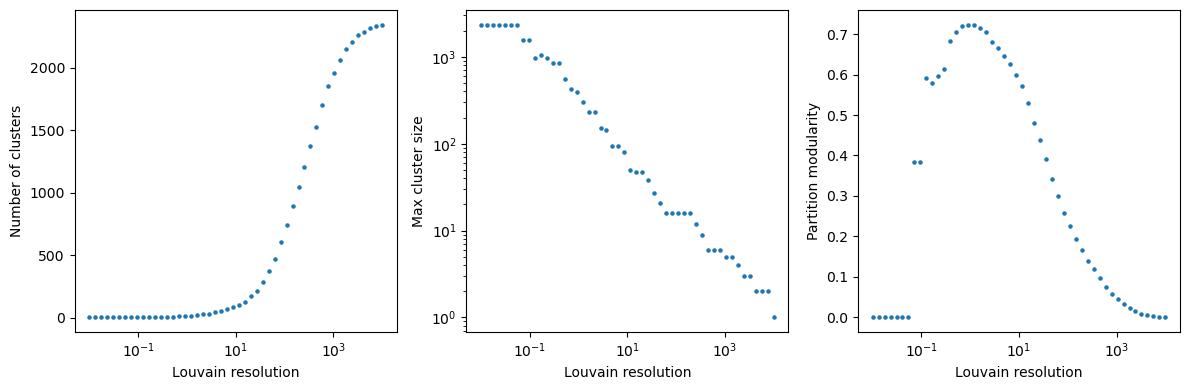

In [24]:
# Choose resolution for Louvain clustering of largest connected component

resolution_ls = np.power(10, np.linspace(-2, 4, 50))
n_clusters = []
modularity_list = []
max_clustersize_list = []
for resolution in tqdm(resolution_ls):
    # Number of clusters
    clusters = nx.community.louvain_communities(
        clique2_largest_cc,
        weight="None",
        resolution=resolution,
        threshold=1e-07,
        seed=13,
    )
    n_clusters.append(len(clusters))
    # Maximum cluster size
    max_clustersize = max([len(c) for c in clusters])
    max_clustersize_list.append(max_clustersize)
    # Modularity
    modularity = nx.community.modularity(clique2_largest_cc, clusters, resolution=1)
    modularity_list.append(modularity)

# t_louvain = 10
t_louvain = resolution_ls[np.argmax(modularity_list)]
print(f"Louvain resolution = {t_louvain}")

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=False)

ax = axs[0]
ax.scatter(resolution_ls, n_clusters, s=5)
# ax.vlines(x=t_louvain, ymin=0, ymax=max(n_clusters), color="red", linestyle="dashed")
ax.set_xscale("log")
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Number of clusters")

ax = axs[1]
ax.scatter(resolution_ls, max_clustersize_list, s=5)
# ax.vlines(
#     x=t_louvain, ymin=0, ymax=max(max_clustersize_list), color="red", linestyle="dashed"
# )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Max cluster size")

ax = axs[2]
ax.scatter(resolution_ls, modularity_list, s=5)
# ax.vlines(
#     x=t_louvain, ymin=0, ymax=max(modularity_list), color="red", linestyle="dashed"
# )
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Partition modularity")

plt.tight_layout()
plt.show()

In [25]:
# Cluster subnetwork
resres = 18
print(resres)

resolution = resres  # t_louvain
clusters = nx.community.louvain_communities(
    clique2_largest_cc, weight="None", resolution=resolution, threshold=1e-07, seed=1234
)
cluster2nodes = {
    f"cluster_{idx}": sorted(clusters[idx]) for idx in range(len(clusters))
}
node2cluster = {}
for k, v in cluster2nodes.items():
    for node in v:
        node2cluster[node] = k

18


In [27]:
# Create list of subclusters of subG_enriched
clique2_subclusters_old = []
for i, cc in tqdm(enumerate(clique2_components)):
    if i == 0:
        for cc_cluster in clusters:
            subcluster_graph = clique_2_subG_old.subgraph(cc_cluster).copy()
            clique2_subclusters_old.append(subcluster_graph)
    else:
        subcluster_graph = clique_2_subG_old.subgraph(cc).copy()
        clique2_subclusters_old.append(subcluster_graph)

15it [00:00, 238.69it/s]


## Load saved clusters

Note that there is some randomness in louvain clustering (even with random seeds) due to node ordering, etc. Thus, we provide and load the clustering results we used for downstream results.

In [63]:
with open("../data/figure3/young_clique2_cluster_graphs.pkl", "rb") as f:
    clique2_subclusters_young = pickle.load(f)
    
with open("../data/figure3/old_clique2_cluster_graphs.pkl", "rb") as f:
    clique2_subclusters_old = pickle.load(f)

# Compute network summaries


For each subnetwork, we look at what pathway genes are expressed, lncRNAs are enriched for binding sites, etc to help identify interesting ones to focus on.

In [31]:
def get_network_summaries(
    network_clusters,
    age,
    ncrna_set,
    young_ncrnas,
    old_ncrnas,
    aging_genesets,
    go_genesets,
    gene_universe,
    locus2genes,
    literature_ncrnas,
    ens2hgnc_dict,
    cutoff=0.05,
    compute_betweenness=True,
    exclude_intra_chrom_enrichment=1,
):
    subnet_index_list = []
    nodes_list = []
    n_nodes_list = []
    chroms_list = []
    n_chroms_list = []
    n_nodes_list = []
    genes_list = []
    n_genes_list = []
    pc_genes_list = []
    n_pc_genes_list = []

    aging_terms_list = []
    n_aging_terms_list = []
    aging_genes_list = []
    aging_n_genes_list = []
    aging_genes_chroms_list = []
    aging_genes_n_chroms_list = []

    go_terms_list = []
    n_go_terms_list = []
    go_genes_list = []
    go_n_genes_list = []
    go_genes_chroms_list = []
    go_genes_n_chroms_list = []

    n_edges_list = []
    n_old_edges_list = []
    n_young_edges_list = []
    n_shared_edges_list = []
    n_pure_edges_list = []

    n_young_ncrnas_list = []
    n_old_ncrnas_list = []
    n_shared_ncrnas_list = []

    density_list = []
    betweenness_age_edges_list = []
    shared_n_ccs_list = []
    shared_n_nodes_largest_cc_list = []
    shared_n_edges_largest_cc_list = []
    all_ncrnas_present_list = []
    n_ncrnas_present_list = []
    most_present_age_ncrna_list = []
    prop_edges_most_present_age_ncrna_list = []
    all_age_ncrnas_present_list = []
    n_age_ncrnas_present_list = []

    most_present_literature_ncrna_list = []
    prop_edges_most_present_literature_ncrna_list = []
    all_literature_ncrnas_present_list = []
    n_literature_ncrnas_present_list = []

    most_present_non_age_ncrna_list = []
    prop_edges_most_present_non_age_ncrna_list = []
    all_non_age_ncrnas_present_list = []
    n_non_age_ncrnas_present_list = []

    for i, subnet in tqdm(list(enumerate(network_clusters))):
        # Nodes
        subnet_index = i
        nodes = sorted(subnet.nodes())
        nodes = ["_loc_".join(n.split("_")[1:3]) for n in nodes]
        chroms = sorted(set([n.split("_")[0] for n in nodes]))
        n_chroms = len(chroms)
        n_nodes = subnet.number_of_nodes()
        genes = sorted(
            set(itertools.chain.from_iterable([locus2genes[n] for n in nodes]))
        )
        n_genes = len(genes)
        pc_genes = sorted(
            set(itertools.chain.from_iterable([locus2pcgenes[n] for n in nodes]))
        )
        n_pc_genes = len(pc_genes)

        # Enrichment
        if (
            len(
                set.intersection(
                    *[
                        set(genes),
                        set(itertools.chain.from_iterable(aging_genesets.values())),
                    ]
                )
            )
            == 0
        ):
            aging_terms = []
            n_aging_terms = 0
            aging_genes = []
            aging_n_genes = []
            aging_genes_chroms = []
            aging_genes_n_chroms = []
        else:
            aging_analysis = perform_go_analysis(
                sorted(list(set(genes).intersection(gene_universe))),
                sorted(gene_universe),
                gene_sets=aging_genesets,
                cutoff=cutoff,
            )
            aging_terms = aging_analysis["Term"].values
            n_aging_terms = len(aging_terms)
            aging_genes = [g_str.split(";") for g_str in aging_analysis["Genes"].values]
            aging_n_genes = [len(g_ls) for g_ls in aging_genes]
            aging_genes_chroms = [
                sorted(set([loc_df.loc[g, "chrom"] for g in g_ls]))
                for g_ls in aging_genes
            ]
            aging_genes_n_chroms = [len(chr_ls) for chr_ls in aging_genes_chroms]

            if exclude_intra_chrom_enrichment > 0:
                mask = np.array(aging_genes_n_chroms) > exclude_intra_chrom_enrichment
                aging_terms = [aging_terms[i] for i in range(len(aging_terms)) if mask[i]]
                n_aging_terms = len(aging_terms)
                aging_genes = [aging_genes[i] for i in range(len(aging_genes)) if mask[i]]
                aging_n_genes = [len(g_ls) for g_ls in aging_genes]
                aging_genes_chroms = [aging_genes_chroms[i] for i in range(len(aging_genes_chroms)) if mask[i]]
                aging_genes_n_chroms = [aging_genes_n_chroms[i] for i in range(len(aging_genes_n_chroms)) if mask[i]]

        if (
            len(
                set.intersection(
                    *[
                        set(genes),
                        set(itertools.chain.from_iterable(go_genesets.values())),
                    ]
                )
            )
            == 0
        ):
            go_terms = []
            n_go_terms = 0
            go_genes = []
            go_n_genes = []
            go_genes_chroms = []
            go_genes_n_chroms = []
        else:
            go_analysis = perform_go_analysis(
                sorted(list(set(genes).intersection(gene_universe))),
                sorted(gene_universe),
                gene_sets=go_genesets,
                cutoff=cutoff,
            )
            go_terms = go_analysis["Term"].values
            n_go_terms = len(go_terms)
            go_genes = [g_str.split(";") for g_str in go_analysis["Genes"].values]
            go_n_genes = [len(g_ls) for g_ls in go_genes]
            go_genes_chroms = [
                sorted(set([loc_df.loc[g, "chrom"] for g in g_ls])) for g_ls in go_genes
            ]
            go_genes_n_chroms = [len(chr_ls) for chr_ls in go_genes_chroms]

            if exclude_intra_chrom_enrichment > 0:
                mask = np.array(go_genes_n_chroms) > exclude_intra_chrom_enrichment
                go_terms = [go_terms[i] for i in range(len(go_terms)) if mask[i]]
                n_go_terms = len(go_terms)
                go_genes = [go_genes[i] for i in range(len(go_genes)) if mask[i]]
                go_n_genes = [len(g_ls) for g_ls in go_genes]
                go_genes_chroms = [go_genes_chroms[i] for i in range(len(go_genes_chroms)) if mask[i]]
                go_genes_n_chroms = [go_genes_n_chroms[i] for i in range(len(go_genes_n_chroms)) if mask[i]]

        # Edges
        n_edges = subnet.number_of_edges()
        young_edges = [
            (u, v) for u, v, att in subnet.edges(data=True) if (att["age"] == "young")
        ]
        old_edges = [
            (u, v) for u, v, att in subnet.edges(data=True) if (att["age"] == "old")
        ]
        shared_edges = [
            (u, v) for u, v, att in subnet.edges(data=True) if (att["age"] == "shared")
        ]
        pure_edges = [
            (u, v)
            for u, v, att in subnet.edges(data=True)
            if (att["age"] == age)
            & (len(set(att["shared_bindingncrna"]) - set(ncrna_set)) == 0)
        ]
        n_pure_edges = len(pure_edges)
        n_young_edges = len(young_edges)
        n_old_edges = len(old_edges)
        n_shared_edges = len(shared_edges)
        density = nx.density(subnet)

        # Betweenness centrality
        edgeset = [
            "-".join(sorted([u, v]))
            for u, v, att in subnet.edges(data=True)
            if (att["age"] == age)
        ]
        if compute_betweenness:
            betweenness_age_edges = edgeset_betweenness_centrality(subnet, edgeset, normalize=True)
        else:
            betweenness_age_edges = 0

        shared_subnetwork = subnet.copy()
        if age == "young":
            shared_subnetwork.remove_edges_from(young_edges)
        elif age == "old":
            shared_subnetwork.remove_edges_from(old_edges)

        n_ccs_shared_edges = nx.number_connected_components(shared_subnetwork)
        largest_shared_cc = max(nx.connected_components(shared_subnetwork), key=len)
        largest_shared_cc = shared_subnetwork.subgraph(largest_shared_cc).copy()
        shared_n_nodes_largest_cc = largest_shared_cc.number_of_nodes()
        shared_n_edges_largest_cc = largest_shared_cc.number_of_edges()

        # ncRNAs
        ncrnas_present = sorted(
            itertools.chain.from_iterable(
                [
                    [ncrna_id for ncrna_id in att["shared_bindingncrna"]]
                    for u, v, att in subnet.edges(data=True)
                    if (att["age"] == age)
                ]
            )
        )

        age_ncrnas_present = [ncrna_id for ncrna_id in ncrnas_present if (ncrna_id in ncrna_set)]
        non_age_ncrnas_present = [ncrna_id for ncrna_id in ncrnas_present if not ncrna_id in ncrna_set]

        all_ncrnas_present = sorted(ncrnas_present)
        n_ncrnas_present = len(set(all_ncrnas_present))

        literature_ncrnas_present = [
            ens2hgnc_dict[ncrna_id]
            for ncrna_id in ncrnas_present
            if (ncrna_id in literature_ncrnas)
        ]

        if len(literature_ncrnas_present) > 0:
            v, n = np.unique(literature_ncrnas_present, return_counts=True)
            most_present_literature_ncrna = v[np.argmax(n)]
            prop_edges_most_present_literature_ncrna = n[np.argmax(n)] / n_edges
            all_literature_ncrnas_present = sorted(literature_ncrnas_present)
            n_literature_ncrnas_present = len(set(all_literature_ncrnas_present))
        else:
            most_present_literature_ncrna = ""
            prop_edges_most_present_literature_ncrna = 0
            all_literature_ncrnas_present = []
            n_literature_ncrnas_present = 0

        n_young_ncrnas = len(set(all_ncrnas_present).intersection(young_ncrnas))
        n_old_ncrnas = len(set(all_ncrnas_present).intersection(old_ncrnas))
        n_shared_ncrnas = n_ncrnas_present - n_young_ncrnas - n_old_ncrnas

        if len(age_ncrnas_present) > 0:
            v, n = np.unique(age_ncrnas_present, return_counts=True)
            most_present_age_ncrna = v[np.argmax(n)]
            prop_edges_most_present_age_ncrna = n[np.argmax(n)] / n_edges
            all_age_ncrnas_present = sorted(age_ncrnas_present)
            n_age_ncrnas_present = len(set(all_age_ncrnas_present))
        else:
            most_present_age_ncrna = ""
            prop_edges_most_present_age_ncrna = 0
            all_age_ncrnas_present = []
            n_age_ncrnas_present = 0

        if len(non_age_ncrnas_present) > 0:
            v, n = np.unique(non_age_ncrnas_present, return_counts=True)
            most_present_non_age_ncrna = v[np.argmax(n)]
            prop_edges_most_present_non_age_ncrna = n[np.argmax(n)] / n_edges
            all_non_age_ncrnas_present = sorted(non_age_ncrnas_present)
            n_non_age_ncrnas_present = len(set(all_non_age_ncrnas_present))
        else:
            most_present_non_age_ncrna = ""
            prop_edges_most_present_non_age_ncrna = 0
            all_non_age_ncrnas_present = []
            n_non_age_ncrnas_present = 0

        subnet_index_list.append(subnet_index)
        nodes_list.append(nodes)
        n_nodes_list.append(n_nodes)
        chroms_list.append(chroms)
        n_chroms_list.append(n_chroms)
        genes_list.append(genes)
        n_genes_list.append(n_genes)
        pc_genes_list.append(pc_genes)
        n_pc_genes_list.append(n_pc_genes)

        aging_terms_list.append(aging_terms)
        n_aging_terms_list.append(n_aging_terms)
        aging_genes_list.append(aging_genes)
        aging_n_genes_list.append(aging_n_genes)
        aging_genes_chroms_list.append(aging_genes_chroms)
        aging_genes_n_chroms_list.append(aging_genes_n_chroms)

        go_terms_list.append(go_terms)
        n_go_terms_list.append(n_go_terms)
        go_genes_list.append(go_genes)
        go_n_genes_list.append(go_n_genes)
        go_genes_chroms_list.append(go_genes_chroms)
        go_genes_n_chroms_list.append(go_genes_n_chroms)

        n_edges_list.append(n_edges)
        n_young_edges_list.append(n_young_edges)
        n_old_edges_list.append(n_old_edges)
        n_pure_edges_list.append(n_pure_edges)
        density_list.append(density)
        betweenness_age_edges_list.append(betweenness_age_edges)
        n_shared_edges_list.append(n_shared_edges)

        n_young_ncrnas_list.append(n_young_ncrnas)
        n_old_ncrnas_list.append(n_old_ncrnas)
        n_shared_ncrnas_list.append(n_shared_ncrnas)

        shared_n_ccs_list.append(n_ccs_shared_edges)
        shared_n_nodes_largest_cc_list.append(shared_n_nodes_largest_cc)
        shared_n_edges_largest_cc_list.append(shared_n_edges_largest_cc)

        all_ncrnas_present_list.append(all_ncrnas_present)
        n_ncrnas_present_list.append(n_ncrnas_present)

        most_present_age_ncrna_list.append(most_present_age_ncrna)
        prop_edges_most_present_age_ncrna_list.append(prop_edges_most_present_age_ncrna)
        all_age_ncrnas_present_list.append(all_age_ncrnas_present)
        n_age_ncrnas_present_list.append(n_age_ncrnas_present)

        most_present_non_age_ncrna_list.append(most_present_non_age_ncrna)
        prop_edges_most_present_non_age_ncrna_list.append(prop_edges_most_present_non_age_ncrna)
        all_non_age_ncrnas_present_list.append(all_non_age_ncrnas_present)
        n_non_age_ncrnas_present_list.append(n_non_age_ncrnas_present)

        most_present_literature_ncrna_list.append(most_present_literature_ncrna)
        prop_edges_most_present_literature_ncrna_list.append(prop_edges_most_present_literature_ncrna)
        all_literature_ncrnas_present_list.append(all_literature_ncrnas_present)
        n_literature_ncrnas_present_list.append(n_literature_ncrnas_present)

    subnets_summary_df = pd.DataFrame(
        {
            "subnet_index": subnet_index_list,
            "nodes": nodes_list,
            "chroms": chroms_list,
            "n_chroms": n_chroms_list,
            "n_nodes": n_nodes_list,
            "genes": genes_list,
            "n_genes": n_genes_list,
            "pc_genes": pc_genes_list,
            "n_pc_genes": n_pc_genes_list,
            "n_pathway_terms": n_go_terms_list,
            "pathway_terms": go_terms_list,
            "pathway_genes": go_genes_list,
            "pathway_n_genes": go_n_genes_list,
            "pathway_genes_chrom": go_genes_chroms_list,
            "pathway_genes_n_chrom": go_genes_n_chroms_list,
            "n_aging_terms": n_aging_terms_list,
            "aging_terms": aging_terms_list,
            "aging_genes": aging_genes_list,
            "aging_n_genes": aging_n_genes_list,
            "aging_genes_chrom": aging_genes_chroms_list,
            "aging_genes_n_chrom": aging_genes_n_chroms_list,
            "n_edges": n_edges_list,
            "n_young_edges": n_young_edges_list,
            "n_old_edges": n_old_edges_list,
            "n_shared_edges": n_shared_edges_list,
            "n_pure_edges": n_pure_edges_list,
            "n_young_ncrnas": n_young_ncrnas_list,
            "n_old_ncrnas": n_old_ncrnas_list,
            "n_shared_ncrnas": n_shared_ncrnas_list,
            "density": density_list,
            "betweenness_age_edges": betweenness_age_edges_list,
            "shared_n_ccs": shared_n_ccs_list,
            "shared_n_nodes_largest_cc": shared_n_nodes_largest_cc_list,
            "shared_n_edges_largest_cc": shared_n_edges_largest_cc_list,
            "all_ncrnas_present": all_ncrnas_present_list,
            "n_ncrnas_present": n_ncrnas_present_list,
            "most_present_age_ncrna": most_present_age_ncrna_list,
            "prop_edges_most_present_age_ncrna": prop_edges_most_present_age_ncrna_list,
            "all_age_ncrnas_present": all_age_ncrnas_present_list,
            "n_age_ncrnas_present": n_age_ncrnas_present_list,
            "most_present_non_age_ncrna": most_present_non_age_ncrna_list,
            "prop_edges_most_present_non_age_ncrna": prop_edges_most_present_non_age_ncrna_list,
            "all_non_age_ncrnas_present": all_non_age_ncrnas_present_list,
            "n_non_age_ncrnas_present": n_non_age_ncrnas_present_list,
            "diff_coverage_most_present_age_vs_non_age_ncrna": [
                prop_edges_most_present_age_ncrna_list[i] - prop_edges_most_present_non_age_ncrna_list[i]
                for i in range(len(prop_edges_most_present_age_ncrna_list))
            ],
            "most_present_literature_ncrna": most_present_literature_ncrna_list,
            "prop_edges_most_present_literature_ncrna": prop_edges_most_present_literature_ncrna_list,
            "all_literature_ncrnas_present": all_literature_ncrnas_present_list,
            "n_literature_ncrnas_present": n_literature_ncrnas_present_list,
        }
    )
    subnets_summary_df["age"] = age
    subnets_summary_df = subnets_summary_df.set_index("subnet_index")
    return subnets_summary_df

In [32]:
def perform_go_analysis(foreground_genes, background_genes, gene_sets, cutoff):
    # Run GO analysis using gseapy
    result = gp.enrichr(
        gene_list=foreground_genes,
        background=background_genes,
        gene_sets=gene_sets,
        outdir=None,  # You can specify an output directory if needed
        cutoff=cutoff,  # Adjust the cutoff as needed
    )
    # Return the enrichment results DataFrame
    out = result.res2d[result.res2d["Adjusted P-value"] < cutoff]
    return out

## Load RNA-seq data

In [33]:
rnaseq_df = pd.read_csv("../data/young_old/youngold_data.csv", header=0, index_col=0)
rnaseq_df["sum_log_count"] = rnaseq_df.log_count_young + rnaseq_df.log_count_old

def add_expression_and_coverage_data(graph, locus2genes, rnaseq_df):
    node_most_expr_gene_dict = {}
    node_sum_log_counts_dict = {}
    node_genes_dict = {}

    for node in tqdm(graph.nodes()):
        ttt = node.split("_")
        other_node_name = "_".join([ttt[1], "loc", ttt[2]])
        genes = sorted(
            set(itertools.chain.from_iterable([locus2genes[other_node_name]]))
        )
        node_genes_dict[node] = genes
        tmp = rnaseq_df.loc[rnaseq_df.hgnc_symbol.isin(genes)].sort_values(
            "sum_log_count", ascending=False
        )
        node_sum_log_counts_dict[node] = np.sum(tmp.loc[:, "sum_log_count"])
        if len(tmp) > 0:
            node_most_expr_gene_dict[node] = tmp.iloc[0]["hgnc_symbol"]
        else:
            node_most_expr_gene_dict[node] = " "
    nx.set_node_attributes(graph, node_most_expr_gene_dict, "most_expressed_gene")
    nx.set_node_attributes(graph, node_sum_log_counts_dict, "sum_log_counts")
    nx.set_node_attributes(graph, node_genes_dict, "covered_genes")

## Load genesets

### Adhesome first

In [34]:
# Load adhesome.org data
components_df = pd.read_csv( "../data/genesets/adhesome/components.csv", header=0, index_col=None)
adhesome_df = components_df[
    ["Official Symbol", "Protein name", "Functional Category", "FA"]
]
adhesome_df.columns = ["hgnc_id", "protein", "functional_category", "FA"]

### Aging

In [2]:
from utils.load_genesets import load_aging_genesets

aging_genesets = load_aging_genesets()

### Reactome

In [37]:
import gseapy as gp

# Reactome gene sets
reactome_genesets = gp.read_gmt("../data/genesets/reactome/c2.cp.reactome.v2023.2.Hs.symbols.gmt")
short_name_reactome_genesets = {}
for k, v in reactome_genesets.items():
    short_name_reactome_genesets[k[k.index("_") + 1 :]] = v

### Aging lncRNAs

In [38]:
aging_ncrnas = pd.read_csv("../data/genesets/aging_ncrnas/aging_ncrnas.txt")
aging_ncrnas["alias"] = aging_ncrnas.alias.str.upper()
aging_ncrnas.head()

,alias,ensembl_id
0,PANDAR,ENSG00000281450
1,MALAT1,ENSG00000251562
2,HOTAIR,ENSG00000228630
3,NEAT1,ENSG00000245532
4,BACE1-AS,ENSG00000278768


In [39]:
litnr_ens2hgnc_dict = dict(
    zip(list(aging_ncrnas.iloc[:, 1]), list(aging_ncrnas.iloc[:, 0]))
)
aging_literature_ncrnas = list(litnr_ens2hgnc_dict.keys())

### Load enriched ncRNAs

In [40]:
# Load ncRNAs of interest
with open("../data/young_old/ncrna_set_dict.json") as f:
    ncrna_set_dict = json.load(f)
    f.close()

# DE ncRNAs
young_up = ncrna_set_dict["ncrnas_de_up_in_young"]
old_up = ncrna_set_dict["ncrnas_de_up_in_old"]

## Load protein coding gene to loci mapping

In [41]:
# Load Ensembl gene locations
ensembl_loc_df = pd.read_csv("../data/genome_data/hg38/chrom_hg38.loc", sep="\t", header=0)
ensembl_loc_df = ensembl_loc_df[["geneName", "#chrom", "chromStart", "chromEnd"]]
ensembl_loc_df = ensembl_loc_df.groupby(["geneName", "#chrom"]).agg(
    {"chromStart": min, "chromEnd": max}
)
ensembl_loc_df = ensembl_loc_df.reset_index()
ensembl_loc_df.columns = ["hgnc_id", "chrom", "chromStart", "chromEnd"]
ensembl_loc_df = ensembl_loc_df.drop_duplicates(subset="hgnc_id")
ensembl_loc_df = ensembl_loc_df.set_index("hgnc_id")
ensembl_loc_df = ensembl_loc_df[
    ensembl_loc_df["chrom"].isin([f"chr{i}" for i in np.arange(1, 22 + 1, 1)])
]

/tmp/ipykernel_3455580/3470260522.py:4: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ensembl_loc_df = ensembl_loc_df.groupby(["geneName", "#chrom"]).agg(
/tmp/ipykernel_3455580/3470260522.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ensembl_loc_df = ensembl_loc_df.groupby(["geneName", "#chrom"]).agg(


In [42]:
# Load ensembl-HGNC mapping
ensembl_hgnc_df = pd.read_csv("../data/genome_data/hgnc2ensembl.csv", sep="\t", header=0)
ensembl_hgnc_df = ensembl_hgnc_df[
    ["Ensembl ID(supplied by Ensembl)", "Approved symbol"]
]
ensembl_hgnc_df.columns = ["ensembl_id", "hgnc_id"]
ensembl_hgnc_df = ensembl_hgnc_df.dropna()
ensembl_hgnc_df = ensembl_hgnc_df.drop_duplicates("hgnc_id")
ensembl_hgnc_df = ensembl_hgnc_df.drop_duplicates("ensembl_id")
ensembl_hgnc_df = ensembl_hgnc_df.set_index("hgnc_id")

In [43]:
# Creat HGNC gene locations
loc_df = pd.concat([ensembl_loc_df, ensembl_hgnc_df], join="inner", axis=1)
loc_df = loc_df.reset_index(drop=False)
loc_df = loc_df[["hgnc_id", "ensembl_id", "chrom", "chromStart", "chromEnd"]]
loc_df = loc_df.set_index("hgnc_id")
loc_df.head()

,ensembl_id,chrom,chromStart,chromEnd
hgnc_id,,,,
A1BG,ENSG00000121410,chr19,58345177,58353492
A1BG-AS1,ENSG00000268895,chr19,58347717,58355455
A1CF,ENSG00000148584,chr10,50799408,50885675
A2M,ENSG00000175899,chr12,9067663,9116229
A2M-AS1,ENSG00000245105,chr12,9065162,9068689


In [44]:
# Create dictionary mapping Ensembl ID to HGNC ID
ensembl2hgnc = {loc_df.loc[idx, "ensembl_id"]: idx for idx in loc_df.index}
hgnc2ensembl = {idx: loc_df.loc[idx, "ensembl_id"] for idx in loc_df.index}

In [45]:
# Load Biomart data for protein coding genes
biomart_df = pd.read_csv(
    "../data/genome_data/biomart_data.csv", sep=",", header=0, index_col=0
)
pc_genes = biomart_df[biomart_df["gene_biotype"] == "protein_coding"][
    "ensembl_gene_id"
].unique()
pc_genes_hgnc = [ensembl2hgnc[g] for g in pc_genes if (g in ensembl2hgnc.keys())]
print(f"Number of protein coding genes = {len(pc_genes_hgnc)}")

Number of protein coding genes = 18294


In [46]:
import pybedtools
resol = 250000
# First, we load chromosome sizes obtined from the UCSC genome browser.
chromsize_df = pd.read_csv("../data/genome_data/hg38/chrom_hg38.sizes", sep="\t")
chromsize_df = chromsize_df[["chrom", "size"]]
chromsize_df = chromsize_df[
    chromsize_df["chrom"].isin(["chr" + str(i) for i in np.arange(1, 22 + 1, 1)])
]

# Divide the chromosomes into loci and make bed file.
df_chrom_list = []
for chrom_id in np.arange(1, 22 + 1):
    chrom = f"chr{chrom_id}"
    chrom_size = chromsize_df[chromsize_df["chrom"] == chrom]["size"].values[0]
    stop_pos = np.arange(resol, chrom_size + resol, resol, dtype="int")
    df_chrom = pd.DataFrame()
    df_chrom["chrom"] = [chrom] * len(stop_pos)
    df_chrom["start"] = stop_pos - resol
    df_chrom["stop"] = stop_pos
    df_chrom_list.append(df_chrom)
segment_df = pd.concat(df_chrom_list, axis=0)
bed_segment = pybedtools.BedTool.from_dataframe(segment_df).sort()

In [47]:

# Map genes to their loci
genes_bed = loc_df.reset_index(drop=False)
genes_bed = genes_bed[["chrom", "chromStart", "chromEnd", "hgnc_id"]]
genes_bed.columns = ["chrom", "chromStart", "chromEnd", "name"]
genes_bed = pybedtools.BedTool.from_dataframe(genes_bed).sort()
out = pybedtools.bedtool.BedTool.map(
    bed_segment, genes_bed, c=4, o="distinct", f=1e-9, F=0.1, e=True
)
out_df = out.to_dataframe()
out_df.columns = ["chrom", "start", "end", "genes"]
out_df.loc[:, "genes"] = out_df["genes"].str.split(",")
out_df.loc[:, "genes"] = out_df["genes"].apply(lambda ls: [] if (ls[0] == ".") else ls)

In [48]:
# Create dictionary mapping loci to genes and to protein coding genes
locus2genes = {}
for idx in out_df.index:
    locus = out_df.loc[idx, "chrom"] + "_loc_" + str(out_df.loc[idx, "start"])
    locus2genes[locus] = out_df.loc[idx, "genes"]

locus2pcgenes = {}
for idx in out_df.index:
    locus = out_df.loc[idx, "chrom"] + "_loc_" + str(out_df.loc[idx, "start"])
    locus2pcgenes[locus] = [g for g in out_df.loc[idx, "genes"] if (g in pc_genes_hgnc)]

### Get network summaries

In [49]:
import itertools
all_nodes = sorted(G.nodes())
all_nodes = ["_loc_".join(n.split("_")[1:3]) for n in all_nodes]
all_covered_genes = sorted(
    set(itertools.chain.from_iterable([locus2genes[n] for n in all_nodes]))
)
print("Genes contained in the overall LAS network", len(all_covered_genes))
covered_pc_genes = set(pc_genes_hgnc).intersection(all_covered_genes)
print("Protein coding genes covered in the overall LAS network", len(covered_pc_genes))

Genes contained in the overall LAS network 24078
Protein coding genes covered in the overall LAS network 12902


### Young network summary

In [50]:
ext_clique2_subclusters = []
for sc in clique2_subclusters_young:
    ext_clique2_subclusters.append(G.subgraph(sc.nodes()))

In [51]:
clique2_subcluster_stats = get_network_summaries(
    ext_clique2_subclusters,
    age="young",
    ncrna_set=young_up,
    young_ncrnas=set(young_up),
    old_ncrnas=set(old_up),
    aging_genesets=aging_genesets,
    go_genesets=short_name_reactome_genesets,
    gene_universe=covered_pc_genes,
    locus2genes=locus2genes,
    literature_ncrnas=aging_literature_ncrnas,
    ens2hgnc_dict=ensembl2hgnc,
    cutoff=0.05,
    compute_betweenness=False,
    exclude_intra_chrom_enrichment=2,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:06<00:00, 18.05it/s]


In [52]:
short_desc_cols = [
    "age",
    "n_nodes",
    "n_edges",
    "n_young_edges",
    "n_old_edges",
    "n_young_ncrnas",
    "n_old_ncrnas",
    "n_genes",
    "n_ncrnas_present",
    "n_age_ncrnas_present",
    "n_pc_genes",
    "n_pathway_terms",
    "n_aging_terms",
    "pathway_n_genes",
    "pathway_genes_n_chrom",
    "pathway_terms",
    "aging_n_genes",
    "aging_genes_n_chrom",
    "most_present_age_ncrna",
    "diff_coverage_most_present_age_vs_non_age_ncrna",
    "prop_edges_most_present_age_ncrna",
    "prop_edges_most_present_non_age_ncrna",
    "prop_edges_most_present_literature_ncrna",
]

tmp = clique2_subcluster_stats.loc[
    (clique2_subcluster_stats.n_young_edges / clique2_subcluster_stats.n_edges > 0.67)
    & (clique2_subcluster_stats.diff_coverage_most_present_age_vs_non_age_ncrna > 0.4)
    & (clique2_subcluster_stats.n_nodes > 10)
]
tmp.loc[:, short_desc_cols].sort_values(["n_pathway_terms"], ascending=False).head(
    10
).iloc[:, :].transpose()

subnet_index,65,96,14,21,94,93,88,82,76,74
age,young,young,young,young,young,young,young,young,young,young
n_nodes,13,11,24,15,16,11,17,12,13,13
n_edges,44,30,181,75,38,34,65,38,43,50
n_young_edges,40,27,147,53,37,27,51,35,36,39
n_old_edges,0,0,0,0,0,0,0,0,0,0
n_young_ncrnas,3,1,4,1,6,2,2,2,1,2
n_old_ncrnas,3,2,6,1,3,2,1,1,2,0
n_genes,109,101,180,95,78,82,91,57,136,50
n_ncrnas_present,88,81,173,121,92,77,92,54,64,79
n_age_ncrnas_present,3,1,4,1,6,2,2,2,1,2


## Old network summary

In [64]:
ext_clique2_subclusters = []
for sc in clique2_subclusters_old:
    ext_clique2_subclusters.append(G.subgraph(sc.nodes()))

In [72]:
clique2_subcluster_stats = get_network_summaries(
    ext_clique2_subclusters,
    age="old",
    ncrna_set=old_up,
    young_ncrnas=set(young_up),
    old_ncrnas=set(old_up),
    aging_genesets=aging_genesets,
    go_genesets=short_name_reactome_genesets,
    gene_universe=covered_pc_genes,
    locus2genes=locus2genes,
    literature_ncrnas=aging_literature_ncrnas,
    ens2hgnc_dict=ensembl2hgnc,
    cutoff=0.05,
    compute_betweenness=False,
    exclude_intra_chrom_enrichment=2,
)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 173/173 [00:09<00:00, 17.82it/s]


In [73]:
short_desc_cols = [
    "age",
    "n_nodes",
    "n_edges",
    "n_young_edges",
    "n_old_edges",
    "n_young_ncrnas",
    "n_old_ncrnas",
    "n_genes",
    "n_ncrnas_present",
    "n_age_ncrnas_present",
    "n_pc_genes",
    "n_pathway_terms",
    "n_aging_terms",
    "pathway_n_genes",
    "pathway_genes_n_chrom",
    "pathway_terms",
    "aging_n_genes",
    "aging_genes_n_chrom",
    "most_present_age_ncrna",
    "diff_coverage_most_present_age_vs_non_age_ncrna",
    "prop_edges_most_present_age_ncrna",
    "prop_edges_most_present_non_age_ncrna",
    "prop_edges_most_present_literature_ncrna",
]

tmp = clique2_subcluster_stats.loc[
    (clique2_subcluster_stats.n_old_edges / clique2_subcluster_stats.n_edges > 0.67)
    & (clique2_subcluster_stats.diff_coverage_most_present_age_vs_non_age_ncrna > 0.4)
    & (clique2_subcluster_stats.n_nodes > 10)
]
tmp.loc[:, short_desc_cols].sort_values(["n_pathway_terms"], ascending=False).head(
    10
).iloc[:, :].transpose()

subnet_index,76,79,0,105,154,149,141,134,129,125
age,old,old,old,old,old,old,old,old,old,old
n_nodes,18,16,16,24,16,23,30,43,17,18
n_edges,36,71,51,171,43,81,141,213,74,79
n_young_edges,0,0,0,2,0,0,3,0,0,0
n_old_edges,27,51,40,120,39,70,109,187,50,58
n_young_ncrnas,3,0,0,3,1,1,1,3,2,3
n_old_ncrnas,3,3,4,5,3,3,4,2,2,4
n_genes,109,105,110,120,66,126,130,85,96,85
n_ncrnas_present,42,92,100,148,46,40,58,65,78,105
n_age_ncrnas_present,3,3,4,5,3,3,4,2,2,4
